In [ ]:
!pip install kaggle

In [ ]:
import json
kaggle_creds = {"username": "XXXXXXXXX", "key": "XXXXXXXXXXXXXXXXXXXX"}
with open("kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d imetomi/eur-usd-forex-pair-historical-data-2002-2019
!unzip eur-usd-forex-pair-historical-data-2002-2019.zip

Dataset URL: https://www.kaggle.com/datasets/imetomi/eur-usd-forex-pair-historical-data-2002-2019
License(s): GNU Affero General Public License 3.0
  0% 0.00/116M [00:00<?, ?B/s]
100% 116M/116M [00:00<00:00, 1.28GB/s]
Archive:  eur-usd-forex-pair-historical-data-2002-2019.zip
  inflating: eurusd_hour.csv         
  inflating: eurusd_minute.csv       
  inflating: eurusd_news.csv         


In [ ]:
import pandas as pd
df = pd.read_csv("eurusd_hour.csv")


In [ ]:
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import math as m
import datetime
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
#cleaning data
display(df)

df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df = df.drop(['Date', 'Time'], axis=1)
df = df.set_index('DateTime')


#predicting on the varaible MID_OPEN Price as that is the most useful
df['MO']=(df['BO']+df['AO'])/2
df = df.drop(['BO', 'AO'], axis=1)#removing these values so information is not redunadant

# Dropping rows with NaN values
df = df.dropna()

# Check dataframe
print(df.shape)
print(df.head())
print(df.index)
display(df)


,Date,Time,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh
0,2005-05-02,00:00,1.28520,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28540,1.28420,1.28460,-0.00080
1,2005-05-02,01:00,1.28440,1.28480,1.28390,1.28420,-0.00020,1.28460,1.28500,1.28410,1.28440,-0.00020
2,2005-05-02,02:00,1.28430,1.28540,1.28410,1.28510,0.00080,1.28450,1.28560,1.28430,1.28530,0.00080
3,2005-05-02,03:00,1.28510,1.28590,1.28500,1.28510,0.00000,1.28530,1.28610,1.28520,1.28530,0.00000
4,2005-05-02,04:00,1.28520,1.28590,1.28490,1.28550,0.00030,1.28540,1.28610,1.28510,1.28570,0.00030
...,...,...,...,...,...,...,...,...,...,...,...,...
93079,2020-04-29,18:00,1.08620,1.08851,1.08611,1.08713,0.00093,1.08660,1.08865,1.08640,1.08726,0.00066
93080,2020-04-29,19:00,1.08711,1.08823,1.08659,1.08748,0.00037,1.08725,1.08837,1.08675,1.08760,0.00035
93081,2020-04-29,20:00,1.08747,1.08788,1.08691,1.08708,-0.00039,1.08758,1.08810,1.08706,1.08808,0.00050
93082,2020-04-29,21:00,1.08708,1.08740,1.08699,1.08714,0.00006,1.08808,1.08814,1.08763,1.08766,-0.00042


(93084, 9)
                         BH      BL      BC     BCh      AH      AL      AC  \
DateTime                                                                      
2005-05-02 00:00:00  1.2852  1.2840  1.2844 -0.0008  1.2854  1.2842  1.2846   
2005-05-02 01:00:00  1.2848  1.2839  1.2842 -0.0002  1.2850  1.2841  1.2844   
2005-05-02 02:00:00  1.2854  1.2841  1.2851  0.0008  1.2856  1.2843  1.2853   
2005-05-02 03:00:00  1.2859  1.2850  1.2851  0.0000  1.2861  1.2852  1.2853   
2005-05-02 04:00:00  1.2859  1.2849  1.2855  0.0003  1.2861  1.2851  1.2857   

                        ACh      MO  
DateTime                             
2005-05-02 00:00:00 -0.0008  1.2853  
2005-05-02 01:00:00 -0.0002  1.2845  
2005-05-02 02:00:00  0.0008  1.2844  
2005-05-02 03:00:00  0.0000  1.2852  
2005-05-02 04:00:00  0.0003  1.2853  
DatetimeIndex(['2005-05-02 00:00:00', '2005-05-02 01:00:00',
               '2005-05-02 02:00:00', '2005-05-02 03:00:00',
               '2005-05-02 04:00:00', '2005-05-

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO
DateTime,,,,,,,,,
2005-05-02 00:00:00,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28420,1.28460,-0.00080,1.285300
2005-05-02 01:00:00,1.28480,1.28390,1.28420,-0.00020,1.28500,1.28410,1.28440,-0.00020,1.284500
2005-05-02 02:00:00,1.28540,1.28410,1.28510,0.00080,1.28560,1.28430,1.28530,0.00080,1.284400
2005-05-02 03:00:00,1.28590,1.28500,1.28510,0.00000,1.28610,1.28520,1.28530,0.00000,1.285200
2005-05-02 04:00:00,1.28590,1.28490,1.28550,0.00030,1.28610,1.28510,1.28570,0.00030,1.285300
...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525


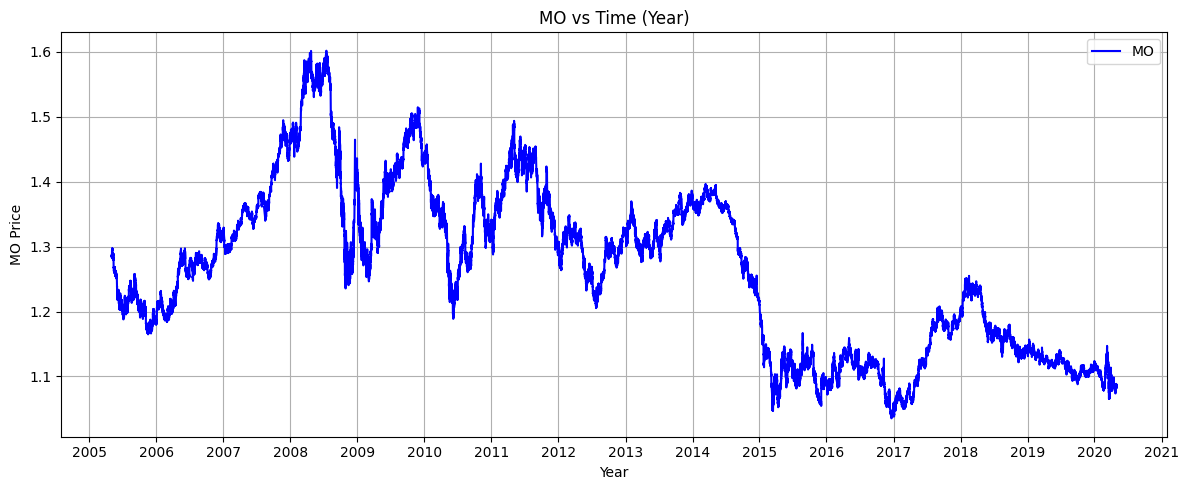

In [ ]:
# Plot MO(the value i wanna predict)
plt.figure(figsize=(12,5))
plt.plot(df.index, df['MO'], color='blue', label='MO')

# Format x-axis to show only year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # one tick per year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year

# Labels and title
plt.xlabel('Year')
plt.ylabel('MO Price')
plt.title('MO vs Time (Year)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Preparing the midprice shifted by n
def linear_reg(df,n):

 df_temp=df
 df_temp['MO_future'] = df_temp['MO'].shift(-n)
 df_temp = df_temp[:-n] #removing last n NaN values

 #defining variables and target variable.Our target variable is future values
 features = ['BH','BL','BC','BCh','AH','AL','AC','ACh']
 X = df_temp[features]
 y = df_temp['MO_future']

 #splitting the datsize into train,evaluatio and test modules

 X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, shuffle=False
 )
 #scaling the dataset


 scaler = StandardScaler()
 X_train = scaler.fit_transform(X_train)

 X_test  = scaler.transform(X_test)
 #testing if partitions make sense
 n_tr  = len(X_train)
 n_tst = len(X_test)


 model = LinearRegression()
 model.fit(X_train, y_train)

 #prediction
 y_pred = model.predict(X_test)

 #prediction on y_train
 y_pred_train=model.predict(X_train)

 #model evaluation
 mse = mean_squared_error(y_test, y_pred)
 rmse= m.sqrt(mse)
 mae=mean_absolute_error(y_test, y_pred)
 r2 = r2_score(y_test, y_pred)
 r2_score_train = r2_score(y_train,y_pred_train)

 comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred , 'Index':y_test.index})

 return r2, model.coef_, mse ,rmse ,mae ,comparison ,r2_score_train

In [ ]:
n=24*7*4 #lets say we wanna predict 1 month
r2,coef,mse,rmse,mae,comparison,r2train=linear_reg(df,n)

#Model evaluation
print("The rmse of test is  : ",rmse)
print("The mae of test is: ",mae)
print("The r2 score test is : ",r2)
print("The r2 score of train is : ",r2train)
print("The difference in absolute values is : ",abs(r2-r2train))
print("The coeficients are : ",coef)
print(comparison.head(10))
display(df)

The rmse of test is  :  0.02330434059063949
The mae of test is:  0.01818389279837467
The r2 score test is :  0.6786982981050731
The r2 score of train is :  0.8782597845227585
The difference in absolute values is :  0.19956148641768545
The coeficients are :  [ 0.88875795  0.67186916 -0.40519191  0.00457478 -1.00120927 -0.52897629
  0.49120118 -0.00429183]
     Actual  Predicted               Index
0  1.090385   1.086898 2017-03-24 02:00:00
1  1.089515   1.087755 2017-03-24 03:00:00
2  1.088675   1.087247 2017-03-24 04:00:00
3  1.088425   1.087618 2017-03-24 05:00:00
4  1.088905   1.087022 2017-03-24 06:00:00
5  1.088815   1.087622 2017-03-24 07:00:00
6  1.088680   1.088032 2017-03-24 08:00:00
7  1.089295   1.090554 2017-03-24 09:00:00
8  1.089180   1.090627 2017-03-24 10:00:00
9  1.089660   1.090958 2017-03-24 11:00:00


,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2005-05-02 00:00:00,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28420,1.28460,-0.00080,1.285300,1.223935
2005-05-02 01:00:00,1.28480,1.28390,1.28420,-0.00020,1.28500,1.28410,1.28440,-0.00020,1.284500,1.224005
2005-05-02 02:00:00,1.28540,1.28410,1.28510,0.00080,1.28560,1.28430,1.28530,0.00080,1.284400,1.224555
2005-05-02 03:00:00,1.28590,1.28500,1.28510,0.00000,1.28610,1.28520,1.28530,0.00000,1.285200,1.223755
2005-05-02 04:00:00,1.28590,1.28490,1.28550,0.00030,1.28610,1.28510,1.28570,0.00030,1.285300,1.223855
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


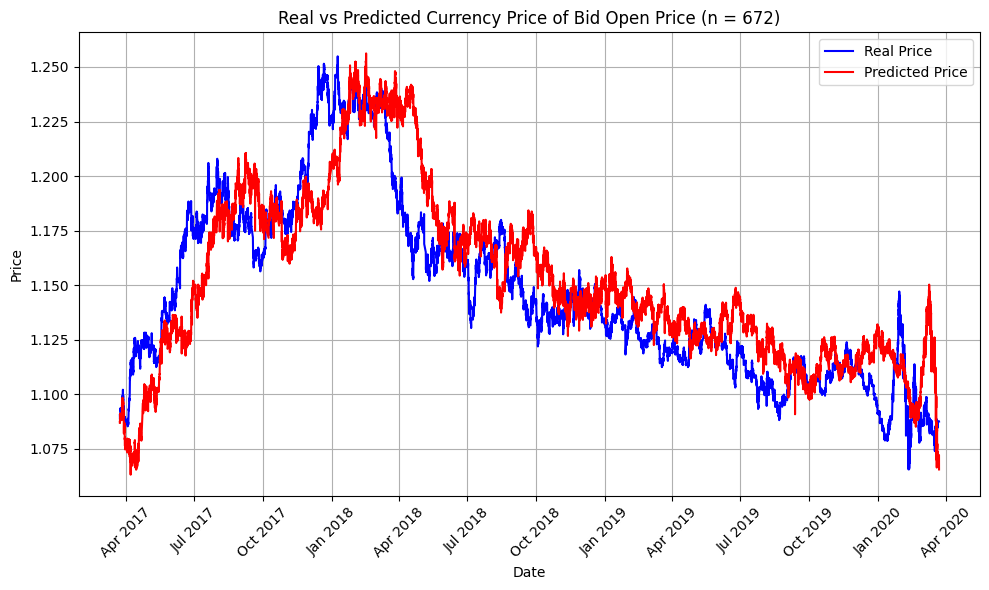

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Plot Actual and Predicted
ax.plot(comparison['Index'], comparison['Actual'], label='Real Price', color='blue')
ax.plot(comparison['Index'], comparison['Predicted'], label='Predicted Price', color='red')

# Format x-axis to show Month and Year
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotate labels
plt.xticks(rotation=45)

# Labels, title, legend, grid
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title(f'Real vs Predicted Currency Price of Bid Open Price (n = {n})')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

DATA PREDICTION USING ARIMA MODEL


In [ ]:
#Data preparation
l = 24*7*2 #cutting the dataframe because my datset to big
n = 24

In [ ]:
display(df)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2005-05-02 00:00:00,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28420,1.28460,-0.00080,1.285300,1.223935
2005-05-02 01:00:00,1.28480,1.28390,1.28420,-0.00020,1.28500,1.28410,1.28440,-0.00020,1.284500,1.224005
2005-05-02 02:00:00,1.28540,1.28410,1.28510,0.00080,1.28560,1.28430,1.28530,0.00080,1.284400,1.224555
2005-05-02 03:00:00,1.28590,1.28500,1.28510,0.00000,1.28610,1.28520,1.28530,0.00000,1.285200,1.223755
2005-05-02 04:00:00,1.28590,1.28490,1.28550,0.00030,1.28610,1.28510,1.28570,0.00030,1.285300,1.223855
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


In [ ]:
df_red = df.iloc[-l:]
display(df_red)
Y_test = df_red['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red['MO'].iloc[:-n]

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-04-09 23:00:00,1.09321,1.09168,1.09193,-0.00057,1.09410,1.09239,1.09267,-0.00062,1.092895,NaN
2020-04-10 00:00:00,1.09246,1.09172,1.09207,0.00014,1.09287,1.09214,1.09237,-0.00022,1.092260,NaN
2020-04-10 01:00:00,1.09263,1.09186,1.09261,0.00050,1.09311,1.09223,1.09311,0.00074,1.092240,NaN
2020-04-10 02:00:00,1.09343,1.09239,1.09326,0.00069,1.09386,1.09281,1.09372,0.00064,1.092825,NaN
2020-04-10 03:00:00,1.09430,1.09297,1.09408,0.00093,1.09472,1.09355,1.09450,0.00083,1.093410,NaN
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


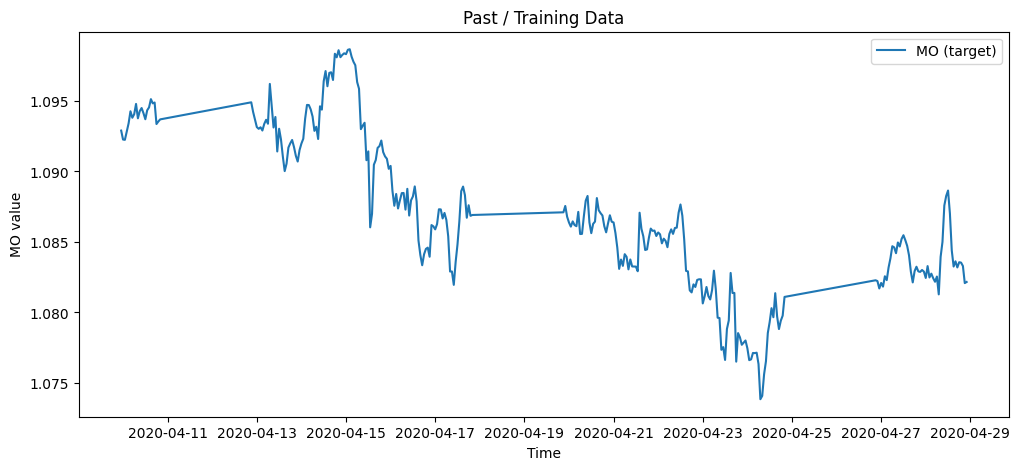

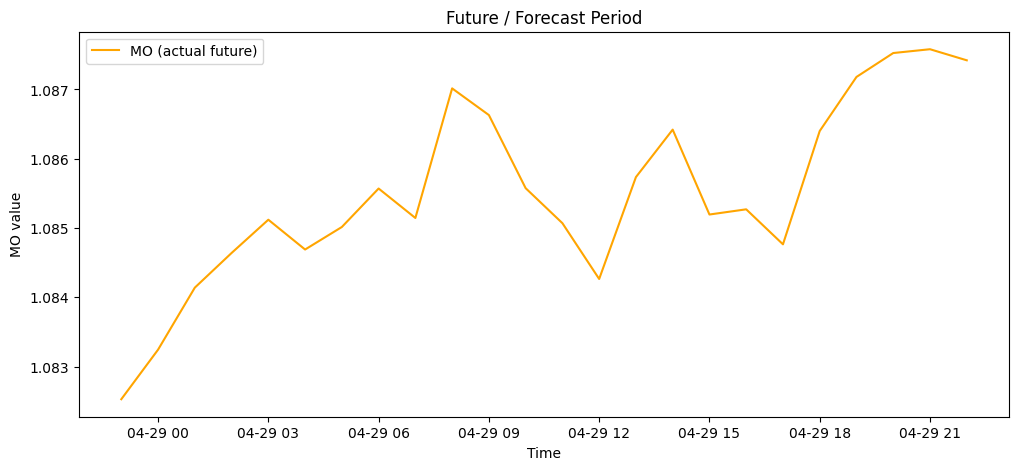

In [ ]:
#visualize both trainn and test
plt.figure(figsize=(12,5))
plt.plot(X_train.index, X_train, label='MO (target)')
plt.title('Past / Training Data')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test, label='MO (actual future)', color='orange')
plt.title('Future / Forecast Period')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

In [ ]:
#building model
p=1 #These values just works
q=1 #These values just works

model = ARIMA(endog=X_train,order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
Y_pred.index=Y_test.index
display(Y_pred)
display(Y_test)

,predicted_mean
DateTime,
2020-04-28 23:00:00,1.082254
2020-04-29 00:00:00,1.082345
2020-04-29 01:00:00,1.082435
2020-04-29 02:00:00,1.082522
2020-04-29 03:00:00,1.082609
2020-04-29 04:00:00,1.082693
2020-04-29 05:00:00,1.082776
2020-04-29 06:00:00,1.082857
2020-04-29 07:00:00,1.082937


,MO
DateTime,
2020-04-28 23:00:00,1.082530
2020-04-29 00:00:00,1.083245
2020-04-29 01:00:00,1.084140
2020-04-29 02:00:00,1.084640
2020-04-29 03:00:00,1.085120
2020-04-29 04:00:00,1.084690
2020-04-29 05:00:00,1.085015
2020-04-29 06:00:00,1.085570
2020-04-29 07:00:00,1.085145


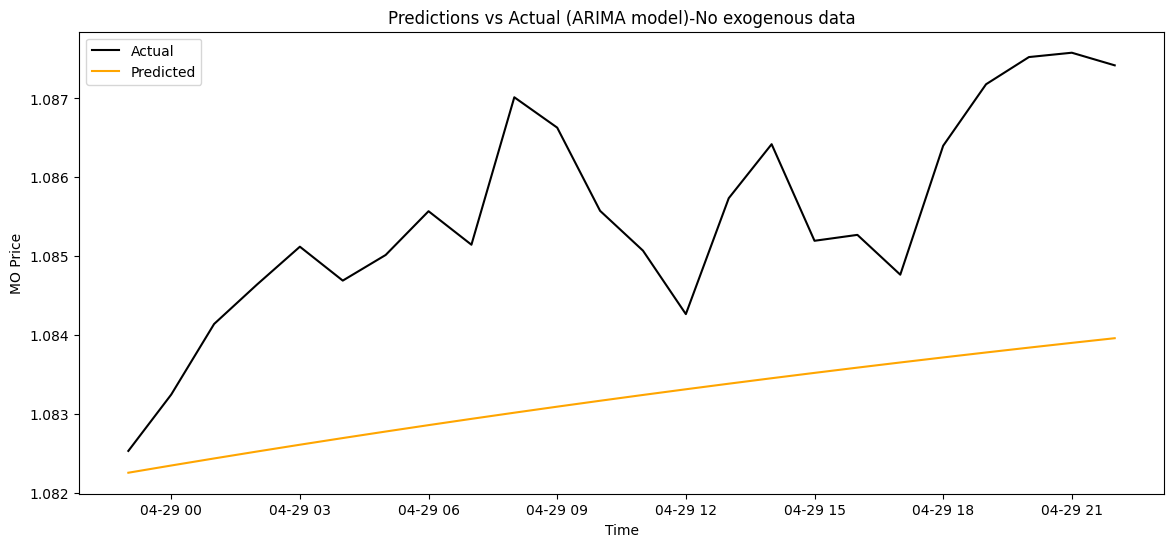

In [ ]:

# Plot
plt.figure(figsize=(14,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMA model)-No exogenous data')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()


SEEING IF TRAINING THE MODEL ON A LONGER TIME PERIOD IMPROVES PREDICTION

In [ ]:
#Data preparation
l = 24*7*4*2 #cutting the dataframe because my datset to big
n = 24*7

In [ ]:
df_red2 = df.iloc[-l:]
display(df_red2)
Y_test = df_red2['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red2['MO'].iloc[:-n]
display(Y_test)
display(X_train)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-02-12 00:00:00,1.09186,1.09113,1.09126,-0.00058,1.09199,1.09126,1.09138,-0.00058,1.091900,1.065915
2020-02-12 01:00:00,1.09192,1.09124,1.09177,0.00052,1.09205,1.09136,1.09190,0.00053,1.091310,1.068905
2020-02-12 02:00:00,1.09193,1.09140,1.09155,-0.00020,1.09205,1.09153,1.09167,-0.00022,1.091820,1.067895
2020-02-12 03:00:00,1.09173,1.09144,1.09148,-0.00007,1.09186,1.09157,1.09159,-0.00010,1.091620,1.071750
2020-02-12 04:00:00,1.09154,1.09116,1.09116,-0.00032,1.09166,1.09128,1.09128,-0.00033,1.091545,1.072915
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,MO
DateTime,
2020-02-12 00:00:00,1.091900
2020-02-12 01:00:00,1.091310
2020-02-12 02:00:00,1.091820
2020-02-12 03:00:00,1.091620
2020-02-12 04:00:00,1.091545
...,...
2020-04-20 18:00:00,1.086875
2020-04-20 19:00:00,1.086115
2020-04-20 20:00:00,1.085680


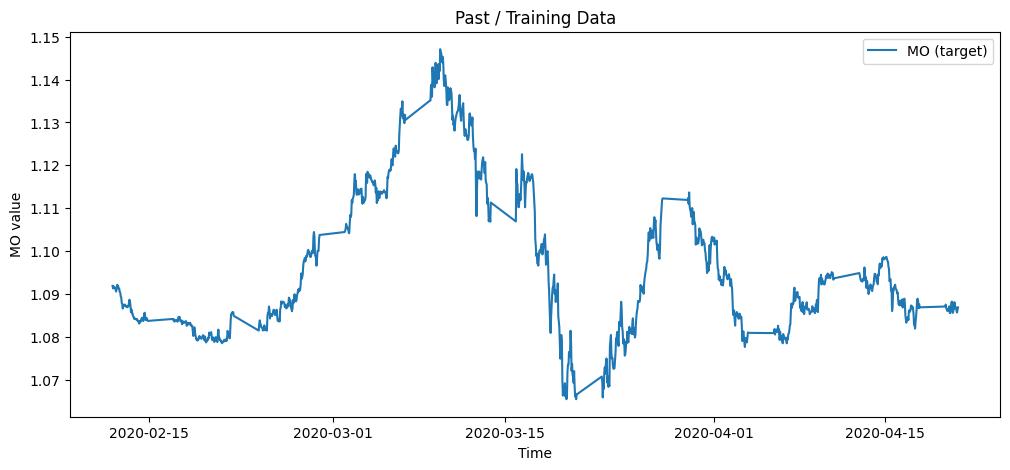

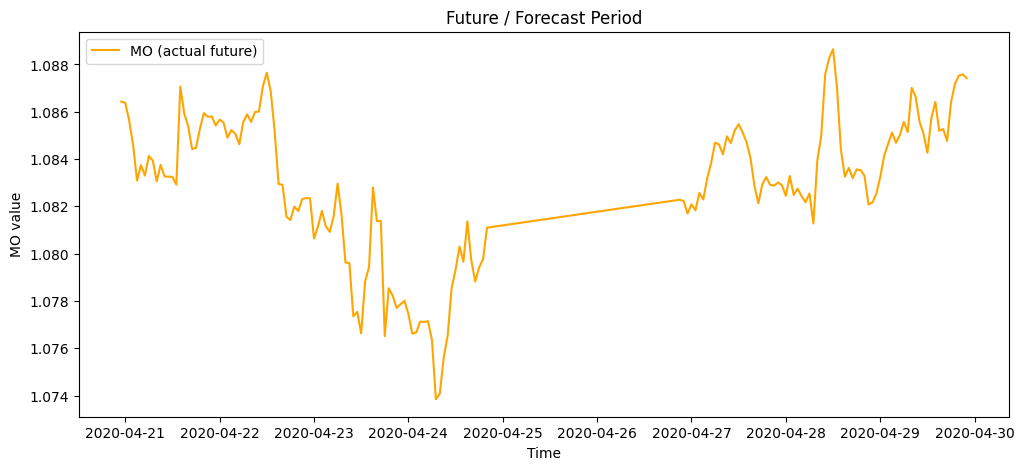

In [ ]:
#visualize both trainn and test
plt.figure(figsize=(12,5))
plt.plot(X_train.index, X_train, label='MO (target)')
plt.title('Past / Training Data')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test, label='MO (actual future)', color='orange')
plt.title('Future / Forecast Period')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

In [ ]:
#Actual ARIMA model
p=1
q=2
model = ARIMA(endog=X_train,order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n)
Y_pred.index=Y_test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
Y_pred.index=Y_test.index
display(Y_test)
display(Y_pred)

,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,predicted_mean
DateTime,
2020-04-20 23:00:00,1.086913
2020-04-21 00:00:00,1.086949
2020-04-21 01:00:00,1.086990
2020-04-21 02:00:00,1.087031
2020-04-21 03:00:00,1.087072
...,...
2020-04-29 18:00:00,1.091727
2020-04-29 19:00:00,1.091747
2020-04-29 20:00:00,1.091767


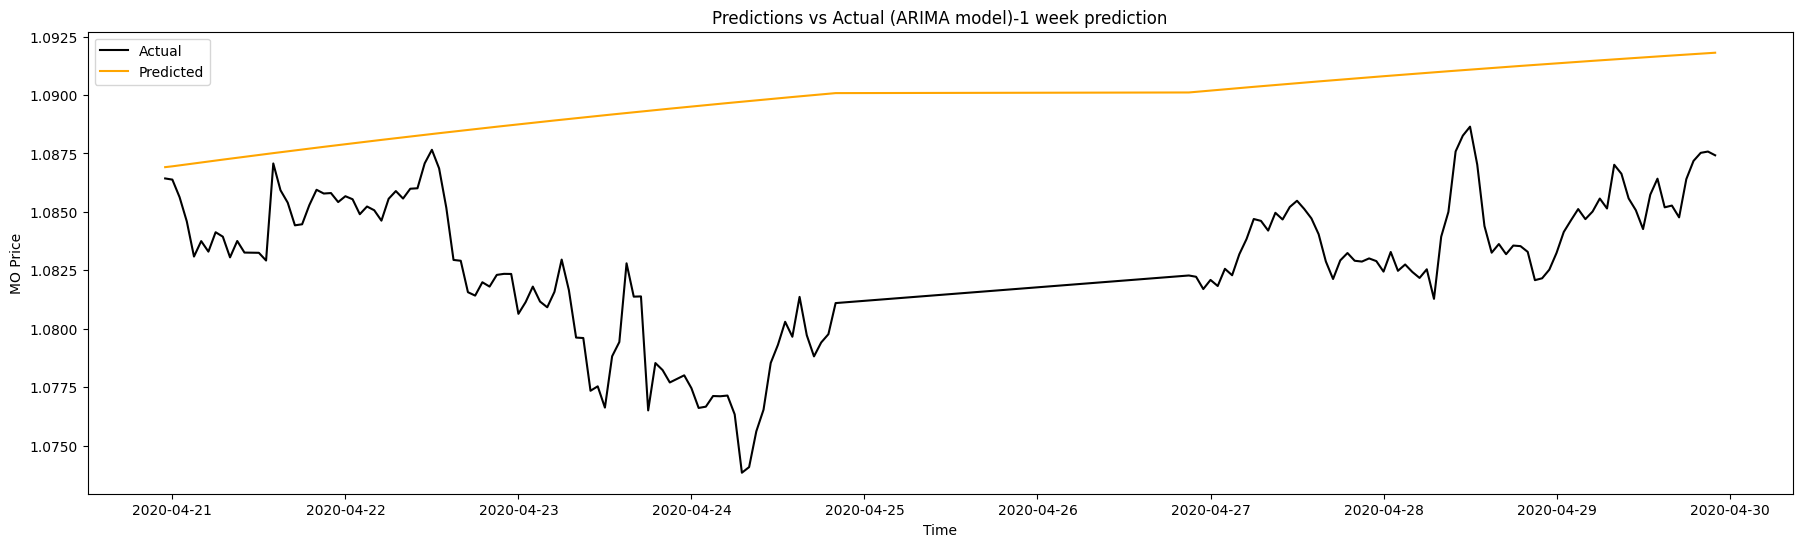

In [ ]:
# Plot
plt.figure(figsize=(22,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMA model)-1 week prediction')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()

HOW ARIMAX MODEL COULD IMPROVE PREDICTION

In [ ]:
#Data preparation
l = 24*7*2 #cutting the dataframe because my datset to big
n = 24*7

In [ ]:
df_red3 = df.iloc[-l:]
display(df_red3)
Y_test = df_red3['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red3['MO'].iloc[:-n]
display(Y_test)
display(X_train)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-04-09 23:00:00,1.09321,1.09168,1.09193,-0.00057,1.09410,1.09239,1.09267,-0.00062,1.092895,NaN
2020-04-10 00:00:00,1.09246,1.09172,1.09207,0.00014,1.09287,1.09214,1.09237,-0.00022,1.092260,NaN
2020-04-10 01:00:00,1.09263,1.09186,1.09261,0.00050,1.09311,1.09223,1.09311,0.00074,1.092240,NaN
2020-04-10 02:00:00,1.09343,1.09239,1.09326,0.00069,1.09386,1.09281,1.09372,0.00064,1.092825,NaN
2020-04-10 03:00:00,1.09430,1.09297,1.09408,0.00093,1.09472,1.09355,1.09450,0.00083,1.093410,NaN
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,MO
DateTime,
2020-04-09 23:00:00,1.092895
2020-04-10 00:00:00,1.092260
2020-04-10 01:00:00,1.092240
2020-04-10 02:00:00,1.092825
2020-04-10 03:00:00,1.093410
...,...
2020-04-20 18:00:00,1.086875
2020-04-20 19:00:00,1.086115
2020-04-20 20:00:00,1.085680


In [ ]:
#We will assume that I can get the values of BH and BL due to thier predictability.We can also assume economic statbility wich will cause these values to not fluctuate.
#defining Exogenous fwetures
exog = df_red3[['BC']]
exog_fut=exog.iloc[-n:]
exog_past=exog.iloc[:-n]

In [ ]:
display(exog_past)
display(X_train)

,BC
DateTime,
2020-04-09 23:00:00,1.09193
2020-04-10 00:00:00,1.09207
2020-04-10 01:00:00,1.09261
2020-04-10 02:00:00,1.09326
2020-04-10 03:00:00,1.09408
...,...
2020-04-20 18:00:00,1.08606
2020-04-20 19:00:00,1.08563
2020-04-20 20:00:00,1.08620


,MO
DateTime,
2020-04-09 23:00:00,1.092895
2020-04-10 00:00:00,1.092260
2020-04-10 01:00:00,1.092240
2020-04-10 02:00:00,1.092825
2020-04-10 03:00:00,1.093410
...,...
2020-04-20 18:00:00,1.086875
2020-04-20 19:00:00,1.086115
2020-04-20 20:00:00,1.085680


In [ ]:
#Actual ARIMAX model
p=0
q=1
model = ARIMA(endog=X_train, exog=exog_past, order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n, exog=exog_fut)
Y_pred.index=Y_test.index


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
Y_pred.index=Y_test.index
display(Y_test)
display(Y_pred)

,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,predicted_mean
DateTime,
2020-04-20 23:00:00,1.086592
2020-04-21 00:00:00,1.085852
2020-04-21 01:00:00,1.084874
2020-04-21 02:00:00,1.083422
2020-04-21 03:00:00,1.084061
...,...
2020-04-29 18:00:00,1.087391
2020-04-29 19:00:00,1.087730
2020-04-29 20:00:00,1.087342


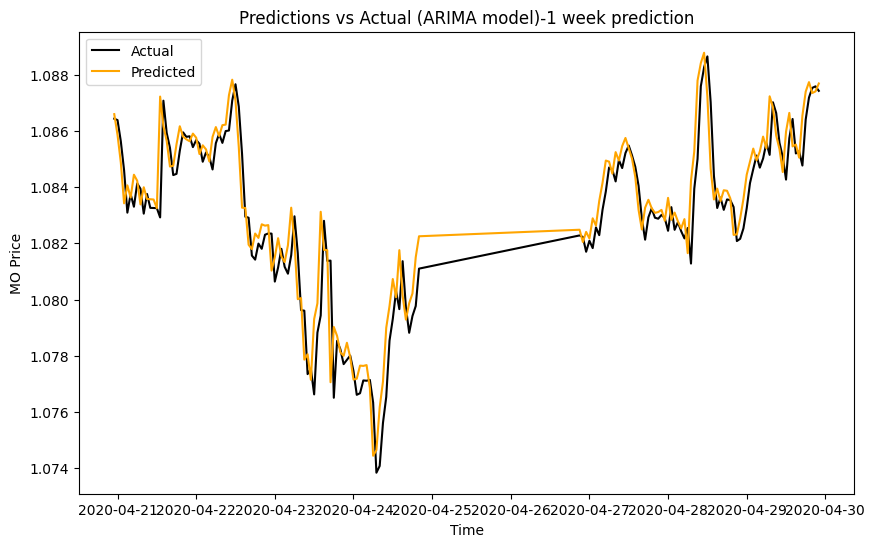

In [ ]:

# Plot
plt.figure(figsize=(10,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMA model)-1 week prediction')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()